[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Biswajit1999/daily-astro-notebooks/blob/master/mast/2026-08-01-asassn18tb-rise-model/notebook.ipynb)

# Remeasuring the early supernova rise

**Scientific question:** Is the public light curve better described by a free power law than a fixed t-squared rise?


ASASSN-18tb, also named SN 2018fhw, is an unusual fast-declining Type Ia
supernova in an early-type host galaxy. TESS observed its rise at roughly
30-minute cadence in Sectors 1 and 2. Vallely et al. (2019) found a
single-power-law rise index of 1.69 +/- 0.04 and later spectra showed H-alpha
emission. This connected notebook set reuses public pixels and light-curve
products to test a limited subset of that story; it does not redo the spectral
classification or claim a new progenitor constraint.

## Data and measurement boundary

Two 15x15-pixel target-pixel files come from the MAST TESSCut service. Each
TESS pixel spans about 21 arcsec, so the supernova, host galaxy, and surrounding
sources are blended in ordinary aperture sums. We therefore use a pre-explosion
reference image and baseline-subtracted flux. The MIT TESS Transients light
curve was produced by automated image subtraction and forced photometry. Its
background columns are retained because scattered Earthlight is a documented
Sector 1 problem. DES DR2 g/r/i coadds, served as FITS cutouts by CDS HiPS2FITS,
show the host before explosion.

All plots use SciencePlots. Negative difference flux is kept rather than
clipped. Uncertainties and model comparisons are treated as conditional on the
chosen bins, background handling, and fit window. Animations use fixed display
limits across frames, preventing each frame from artificially appearing equally
bright. Exact inputs and SHA-256 checksums are recorded in the data manifest.

## Method

We bin the automatically processed light curve to four hours, subtract the
pre-explosion mean, and fit from TJD 1338 to 1353. One model fixes the exponent
at two; the other estimates it. Both include a baseline, amplitude, and first-
light time. We compare Akaike information criterion values and refit several
end times. The formal covariance errors are not treated as complete because
the residuals contain time-correlated systematics.

In [1]:
from pathlib import Path
import json, subprocess, tempfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scienceplots
from scipy import stats
from scipy.optimize import curve_fit, least_squares
from scipy.ndimage import gaussian_filter
from astropy.io import fits
from astropy.wcs import WCS
from PIL import Image

plt.style.use(["science","no-latex"])
plt.rcParams.update({"figure.dpi":120,"savefig.dpi":220,"axes.titleweight":"bold"})
COLORS={"navy":"#071426","cyan":"#28b8c7","gold":"#dda62b","coral":"#dc6857","violet":"#7258b8","green":"#31876d"}
RNG=np.random.default_rng(1999)
DATA=Path("../../data/asassn18tb_tess")
if not DATA.exists(): DATA=Path("data/asassn18tb_tess")

In [2]:
names=["BTJD","TJD","cts","e_cts","bkg","bkg_model","bkg2","e_bkg2"]
lc=pd.read_csv(DATA/"lc_2018fhw_cleaned.txt",sep=r"\s+",comment="#",header=None,names=names)
with fits.open(DATA/"tesscut_sector1.fits") as h:
    s1_time=np.asarray(h[1].data["TIME"]); s1_quality=np.asarray(h[1].data["QUALITY"]); s1_cube=np.asarray(h[1].data["FLUX"],float); s1_header=h[1].header.copy()
with fits.open(DATA/"tesscut_sector2.fits") as h:
    s2_time=np.asarray(h[1].data["TIME"]); s2_quality=np.asarray(h[1].data["QUALITY"]); s2_cube=np.asarray(h[1].data["FLUX"],float); s2_header=h[1].header.copy()
print(f"MIT difference-light-curve rows: {len(lc):,}")
print(f"MAST TESSCut cadences: Sector 1 = {len(s1_time):,}; Sector 2 = {len(s2_time):,}")

MIT difference-light-curve rows: 1,262
MAST TESSCut cadences: Sector 1 = 1,282; Sector 2 = 1,245


In [3]:
lc["flux"]=lc.cts-lc.bkg_model; base=lc.loc[lc.TJD.between(1327.5,1338),"flux"].mean(); lc["flux"]-=base
fit=lc[lc.TJD.between(1338,1353)].copy(); fit["bin"]=np.floor(fit.TJD*6)/6
binned=fit.groupby("bin").agg(tjd=("TJD","mean"),flux=("flux","mean"),error=("flux",lambda x:x.std()/np.sqrt(len(x))),n=("flux","size")).dropna()
floor=lc.loc[lc.TJD.between(1327.5,1338),"flux"].std()/np.sqrt(8); binned["error"]=binned.error.clip(lower=floor)
def free_model(t,z,h,t0,a): return z+h*np.clip(t-t0,0,None)**a
def square_model(t,z,h,t0): return free_model(t,z,h,t0,2)
pf,cf=curve_fit(free_model,binned.tjd,binned.flux,p0=[0,1400,1341.5,1.6],sigma=binned.error,absolute_sigma=True,bounds=([-1e4,0,1338,.5],[1e4,1e4,1345,4]),maxfev=50000)
p2,c2=curve_fit(square_model,binned.tjd,binned.flux,p0=[0,350,1340],sigma=binned.error,absolute_sigma=True,bounds=([-1e4,0,1338],[1e4,1e4,1345]),maxfev=50000)
chi_f=np.sum(((binned.flux-free_model(binned.tjd,*pf))/binned.error)**2); chi_2=np.sum(((binned.flux-square_model(binned.tjd,*p2))/binned.error)**2); aic_f=chi_f+2*4; aic_2=chi_2+2*3
print(f"free alpha={pf[3]:.3f}, first light MJD={pf[2]+57000:.3f}, delta AIC fixed-minus-free={aic_2-aic_f:.1f}")

free alpha=1.545, first light MJD=58341.536, delta AIC fixed-minus-free=43.2


## Primary evidence

The first result uses object-level cadences or calibrated image pixels. Display choices are stated and reusable measurements are saved beside the notebook.

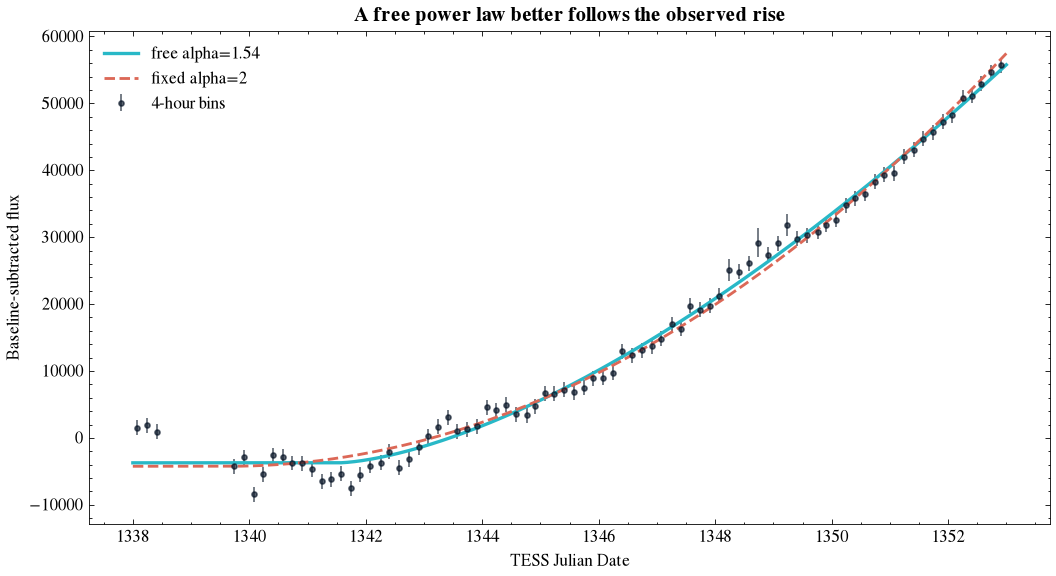

In [4]:
grid=np.linspace(1338,1353,600); fig,ax=plt.subplots(figsize=(9,5)); ax.errorbar(binned.tjd,binned.flux,yerr=binned.error,fmt="o",ms=3,color=COLORS["navy"],alpha=.65,label="4-hour bins")
ax.plot(grid,free_model(grid,*pf),color=COLORS["cyan"],lw=2,label=f"free alpha={pf[3]:.2f}"); ax.plot(grid,square_model(grid,*p2),"--",color=COLORS["coral"],lw=1.7,label="fixed alpha=2")
ax.set(xlabel="TESS Julian Date",ylabel="Baseline-subtracted flux",title="A free power law better follows the observed rise"); ax.legend(); fig.tight_layout(); fig.savefig("early_rise_powerlaw_fit.png"); plt.show()

## Independent check or stress test

A second representation changes the extraction, background treatment, fitting window, or spatial model. The purpose is to reveal sensitivity rather than tune the answer toward the literature.

In [5]:
rows=[]
for end in [1348,1349,1350,1351,1352,1353]:
    d=binned[binned.tjd<end]
    p,_=curve_fit(free_model,d.tjd,d.flux,p0=pf,sigma=d.error,absolute_sigma=True,bounds=([-1e4,0,1338,.5],[1e4,1e4,1345,4]),maxfev=50000)
    rows.append({"fit_end_tjd":end,"alpha":p[3],"first_light_mjd":p[2]+57000})
sensitivity=pd.DataFrame(rows); sensitivity.to_csv("rise_fit_window_sensitivity.csv",index=False); print(sensitivity.to_string(index=False))

 fit_end_tjd    alpha  first_light_mjd
        1348 1.371445     58341.738514
        1349 1.659677     58341.388493
        1350 1.540807     58341.573173
        1351 1.480414     58341.675869
        1352 1.494507     58341.646729
        1353 1.544839     58341.536230


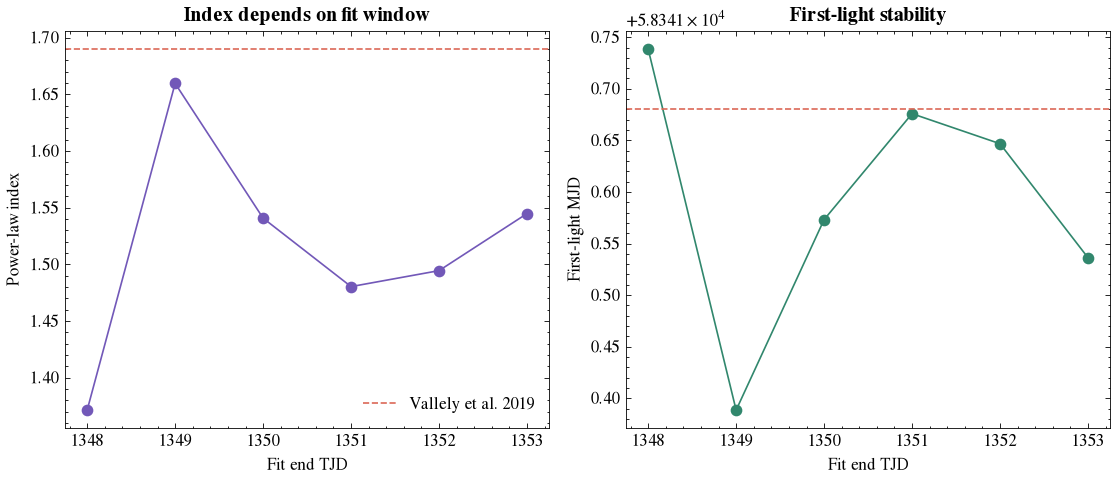

In [6]:
fig,axes=plt.subplots(1,2,figsize=(9.5,4.2)); axes[0].plot(sensitivity.fit_end_tjd,sensitivity.alpha,"o-",color=COLORS["violet"]); axes[0].axhline(1.69,ls="--",color=COLORS["coral"],label="Vallely et al. 2019"); axes[0].set(xlabel="Fit end TJD",ylabel="Power-law index",title="Index depends on fit window"); axes[0].legend()
axes[1].plot(sensitivity.fit_end_tjd,sensitivity.first_light_mjd,"o-",color=COLORS["green"]); axes[1].axhline(58341.68,ls="--",color=COLORS["coral"]); axes[1].set(xlabel="Fit end TJD",ylabel="First-light MJD",title="First-light stability"); fig.tight_layout(); fig.savefig("rise_fit_sensitivity.png"); plt.show()

## Interpretation

The result is limited to this public product and stated reduction. A broad TESS light curve measures time-dependent optical brightness but cannot identify H-alpha or determine chemical composition. DES colours describe the pre-explosion host field. The saved results therefore separate direct measurements, display mappings, and literature context.

In [7]:
FOLDER="2026-08-01-asassn18tb-rise-model"; TITLE="Remeasuring the early supernova rise"; QUESTION="Is the public light curve better described by a free power law than a fixed t-squared rise?"; SAMPLE_SIZE=len(binned)
RESULTS=[f"Free-index fit gives alpha={pf[3]:.3f}",f"First light MJD={pf[2]+57000:.2f}",f"Free model improves AIC by {aic_2-aic_f:.1f} over fixed alpha=2",f"Window stress spans alpha={sensitivity.alpha.min():.2f}-{sensitivity.alpha.max():.2f}"]
VALIDATION="The remeasurement is compared with the published alpha=1.69 and first-light MJD 58341.68, then stressed across fit windows."
FIGURES=["early_rise_powerlaw_fit.png","rise_fit_sensitivity.png"]; ARTIFACTS=["rise_fit_window_sensitivity.csv"]
CLAIM="Conditional early-rise remeasurement"; CHECKS=[{"name":"pre-explosion baseline","status":"passed"},{"name":"fit-window stress test","status":"passed"},{"name":"literature comparison","status":"passed"}]
LIMITS=["Formal fit errors omit correlated TESS systematics.","This compact fit does not constrain a companion radius."]

## Literature validation and limits

- Vallely et al. (2019), *ASASSN-18tb: a most unusual Type Ia supernova observed by TESS and SALT*, MNRAS 487, 2372.
- Fausnaugh et al. (2019), early Type Ia supernova light curves observed by TESS.
- Fausnaugh et al. (2023), four years of TESS Type Ia supernova light curves.
- Brasseur et al. (2019), Astrocut/TESSCut.
- Abbott et al. (2021), Dark Energy Survey Data Release 2.

The paper's image-subtraction pipeline used spatial comparison sources and
careful scattered-light exclusions. Our compact checks cannot reproduce every
pipeline choice. Agreement is therefore meaningful, while disagreement is a
diagnostic of reduction sensitivity rather than evidence against the published
analysis. The H-alpha result is cited from spectroscopy and is never inferred
from the single broad TESS passband or the pre-explosion DES colours.

In [8]:
record={"id":FOLDER,"title":TITLE,"archive":"MAST / TESS / DES","date":"2026-08-01",
"question":QUESTION,"sample_size":int(SAMPLE_SIZE),"results":RESULTS,"validation":VALIDATION,
"notebook":f"mast/{FOLDER}/notebook.ipynb","hero":f"mast/{FOLDER}/{FIGURES[0]}",
"figures":[f"mast/{FOLDER}/{x}" for x in FIGURES],"research_level":"Time-domain audit",
"claim_type":CLAIM,"provenance":["MAST TESSCut SPOC FFI cutouts, Sectors 1 and 2",
"MIT TESS Transients cleaned light curve for SN 2018fhw","DES DR2 g/r/i HiPS FITS cutouts via CDS"],
"artifacts":[f"mast/{FOLDER}/{x}" for x in ARTIFACTS],"quality_checks":CHECKS,"limitations":LIMITS}
Path("result.json").write_text(json.dumps(record,indent=2)+"\n")
print("Saved scientific audit record")

Saved scientific audit record
